# Double Descent / Complexity Curve Investigation

**Hypothesis:** The current XGB+Elo model sits in the first descent valley — early stopping cuts it off
before it can reach a potential second descent. We map the full loss-vs-complexity curve by:

1. Training at many fixed round counts (no early stopping) to see the full curve shape
2. Varying effective model complexity along other axes (depth, min_child_weight, n_features)
3. Testing constrained configs that might extract signal more cleanly

All evaluation uses the same walk-forward OOF scheme (test on 2020-2024) as the main pipeline.

In [2]:
import warnings
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path

import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.metrics import log_loss, brier_score_loss, accuracy_score
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

warnings.filterwarnings("ignore")
%matplotlib inline

PROJECT_ROOT = Path("..").resolve()
GOLD_DIR     = PROJECT_ROOT / "data" / "gold"
OUT_DIR      = PROJECT_ROOT / "data" / "complexity_curve"
OUT_DIR.mkdir(parents=True, exist_ok=True)

CLIP_EPS    = 1e-6
OOF_YEARS   = list(range(2020, 2025))
TRAIN_START = 2015
N_PLAYERS   = 7
N_WORKERS   = 4
NTHREAD     = 4

print(f"Project root: {PROJECT_ROOT}")
print(f"Parallelism: {N_WORKERS} workers x nthread={NTHREAD}")

Project root: C:\Users\arius\Desktop\kalshi_wnba_bot
Parallelism: 4 workers x nthread=4


In [3]:
# --- Feature column definitions ---
PLAYER_MODEL_FEATURES = [
    "m_ewma_pre", "q_pre", "days_since_first_report_pre",
    "days_since_last_dnp_pre", "consec_dnps_pre", "played_last_game_pre",
    "minutes_last_game_pre", "days_since_last_played_pre",
    "injury_present_flag_pre",
]
RECENT_FORM_FEATURES = [
    "net_rtg_ewma_pre", "efg_ewma_pre", "tov_pct_ewma_pre",
    "orb_pct_ewma_pre", "ftr_ewma_pre",
]
STYLE_FEATURES = [
    "off_3pa_rate_pre", "def_3pa_allowed_pre", "off_2pa_rate_pre",
    "def_2pa_allowed_pre", "off_tov_pct_pre", "def_forced_tov_pre",
]
SCHEDULE_FEATURES = [
    "days_rest_pre", "is_b2b_pre", "games_last_4_days_pre",
    "games_last_7_days_pre", "travel_miles_pre", "timezone_shift_hours_pre",
]

def build_feature_cols(n_players: int) -> list[str]:
    cols = []
    for side in ("home", "away"):
        for slot in range(1, n_players + 1):
            for feat in PLAYER_MODEL_FEATURES:
                cols.append(f"{side}_p{slot}_{feat}")
    for feat in RECENT_FORM_FEATURES:
        cols.append(f"home_{feat}")
        cols.append(f"away_{feat}")
    for feat in STYLE_FEATURES:
        cols.append(f"home_{feat}")
        cols.append(f"away_{feat}")
    for feat in SCHEDULE_FEATURES:
        cols.append(f"home_{feat}")
        cols.append(f"away_{feat}")
    return cols

FEATURE_COLS = build_feature_cols(N_PLAYERS)
print(f"Feature columns: {len(FEATURE_COLS)}")

Feature columns: 160


In [4]:
# --- Data loaders & helpers ---
def load_gold(season: int) -> pd.DataFrame:
    p = GOLD_DIR / f"game_xgboost_input_{season}_REGPST.csv"
    if not p.exists():
        raise FileNotFoundError(f"Missing: {p}")
    df = pd.read_csv(p)
    df["season"] = df["season"].astype(int)
    cold = (df["home_p1_m_ewma_pre"] == 0) | (df["away_p1_m_ewma_pre"] == 0)
    n_drop = cold.sum()
    if n_drop:
        df = df[~cold].reset_index(drop=True)
        print(f"  [load {season}] dropped {n_drop} cold-start rows")
    return df

def load_range(start: int, end: int) -> pd.DataFrame:
    dfs = []
    for y in range(start, end + 1):
        try:
            dfs.append(load_gold(y))
        except FileNotFoundError as e:
            print(f"  WARNING: {e}")
    return pd.concat(dfs, ignore_index=True).dropna(subset=["home_win", "base_margin"])

def clip(p):
    return np.clip(p, CLIP_EPS, 1 - CLIP_EPS)

def logit(p):
    p = clip(p)
    return np.log(p / (1 - p))

def metrics(y, p):
    p = clip(p)
    return {
        "log_loss":  log_loss(y, p),
        "brier":     brier_score_loss(y, p),
        "accuracy":  accuracy_score(y, (p >= 0.5).astype(int)),
        "n_games":   len(y),
    }

In [5]:
# --- Pre-load all fold data ---
# For each OOF fold year Y:
#   train = 2015..Y-1, test = Y
# We store pre-built arrays to avoid reloading in every experiment.

fold_data = {}
for test_year in OOF_YEARS:
    train_df = load_range(TRAIN_START, test_year - 1)
    test_df  = load_gold(test_year).dropna(subset=["home_win", "base_margin"])
    avail = [c for c in FEATURE_COLS if c in train_df.columns]
    fold_data[test_year] = {
        "X_train":  train_df[avail].values.astype(float),
        "y_train":  train_df["home_win"].values.astype(float),
        "bm_train": train_df["base_margin"].values.astype(float),
        "X_test":   test_df[avail].values.astype(float),
        "y_test":   test_df["home_win"].values.astype(float),
        "bm_test":  test_df["base_margin"].values.astype(float),
        "p_elo":    clip(test_df["p_elo"].values.astype(float)),
        "avail":    avail,
    }
    print(f"Fold {test_year}: train={len(train_df)}, test={len(test_df)}")

# Elo baseline per fold
elo_ll_per_fold = {}
for y in OOF_YEARS:
    fd = fold_data[y]
    elo_ll_per_fold[y] = log_loss(fd["y_test"], fd["p_elo"])

elo_ll_overall = np.mean(list(elo_ll_per_fold.values()))
print(f"\nElo baseline mean OOF LL: {elo_ll_overall:.6f}")

  [load 2015] dropped 7 cold-start rows
Fold 2020: train=1098, test=147
  [load 2015] dropped 7 cold-start rows
Fold 2021: train=1245, test=209
  [load 2015] dropped 7 cold-start rows
Fold 2022: train=1454, test=239
  [load 2015] dropped 7 cold-start rows
Fold 2023: train=1693, test=260
  [load 2015] dropped 7 cold-start rows
Fold 2024: train=1953, test=262

Elo baseline mean OOF LL: 0.601842


## Experiment 1 — Complexity Curve: Fixed Rounds (No Early Stopping)

Train XGB+Elo at many fixed round counts from 1 to 5000. No early stopping.
This maps out the full loss curve to see if there is a second descent past the
interpolation peak.

We use the **current frozen params** as the base, just varying `num_boost_round`.

In [6]:
BASE_PARAMS = {
    "objective":        "binary:logistic",
    "eval_metric":      "logloss",
    "max_depth":        6,
    "min_child_weight": 3,
    "subsample":        0.8,
    "colsample_bytree": 0.6,
    "reg_lambda":       1.0,
    "reg_alpha":        0.0,
    "gamma":            1.0,
    "learning_rate":    0.02,
    "seed":             42,
    "nthread":          NTHREAD,
}

ROUND_SCHEDULE = [1, 2, 5, 10, 20, 50, 100, 150, 200, 300, 500, 750, 1000, 1500, 2000, 3000, 5000]

def run_fixed_rounds(params, n_rounds, fold_data_dict):
    """Train XGB+Elo for exactly n_rounds on each fold. Return per-fold and mean OOF log loss."""
    fold_lls = {}
    for test_year, fd in fold_data_dict.items():
        dm_train = xgb.DMatrix(
            data=fd["X_train"], label=fd["y_train"],
            base_margin=fd["bm_train"], missing=np.nan)
        dm_test = xgb.DMatrix(
            data=fd["X_test"], label=fd["y_test"],
            base_margin=fd["bm_test"], missing=np.nan)
        model = xgb.train(params, dm_train, num_boost_round=n_rounds, verbose_eval=False)
        preds = clip(model.predict(dm_test))
        fold_lls[test_year] = log_loss(fd["y_test"], preds)
    return fold_lls, np.mean(list(fold_lls.values()))

def _run_one_config(params, n_rounds):
    """Worker function for parallel execution."""
    fold_lls, mean_ll = run_fixed_rounds(params, n_rounds, fold_data)
    return params, n_rounds, fold_lls, mean_ll

print(f"Running {len(ROUND_SCHEDULE)} round counts x {len(OOF_YEARS)} folds ...")
exp1_results = []
with ThreadPoolExecutor(max_workers=N_WORKERS) as ex:
    futures = {ex.submit(_run_one_config, BASE_PARAMS, nr): nr for nr in ROUND_SCHEDULE}
    for fut in as_completed(futures):
        _, n_rounds, fold_lls, mean_ll = fut.result()
        exp1_results.append({"n_rounds": n_rounds, "mean_ll": mean_ll,
                             **{f"ll_{y}": fold_lls[y] for y in OOF_YEARS}})
        print(f"  rounds={n_rounds:5d}  mean_LL={mean_ll:.6f}")

exp1_df = pd.DataFrame(exp1_results).sort_values("n_rounds").reset_index(drop=True)
exp1_df.to_csv(OUT_DIR / "exp1_rounds_curve.csv", index=False)
print("Done.")

Running 17 round counts x 5 folds ...
  rounds=    1  mean_LL=0.601296
  rounds=    2  mean_LL=0.601457
  rounds=    5  mean_LL=0.601876
  rounds=   10  mean_LL=0.601368
  rounds=   20  mean_LL=0.600118
  rounds=   50  mean_LL=0.602128
  rounds=  100  mean_LL=0.605251
  rounds=  150  mean_LL=0.608925
  rounds=  200  mean_LL=0.610473
  rounds=  300  mean_LL=0.619950
  rounds=  500  mean_LL=0.635642
  rounds=  750  mean_LL=0.642970
  rounds= 1000  mean_LL=0.645898
  rounds= 1500  mean_LL=0.650031
  rounds= 2000  mean_LL=0.652081
  rounds= 3000  mean_LL=0.654437
  rounds= 5000  mean_LL=0.657040
Done.


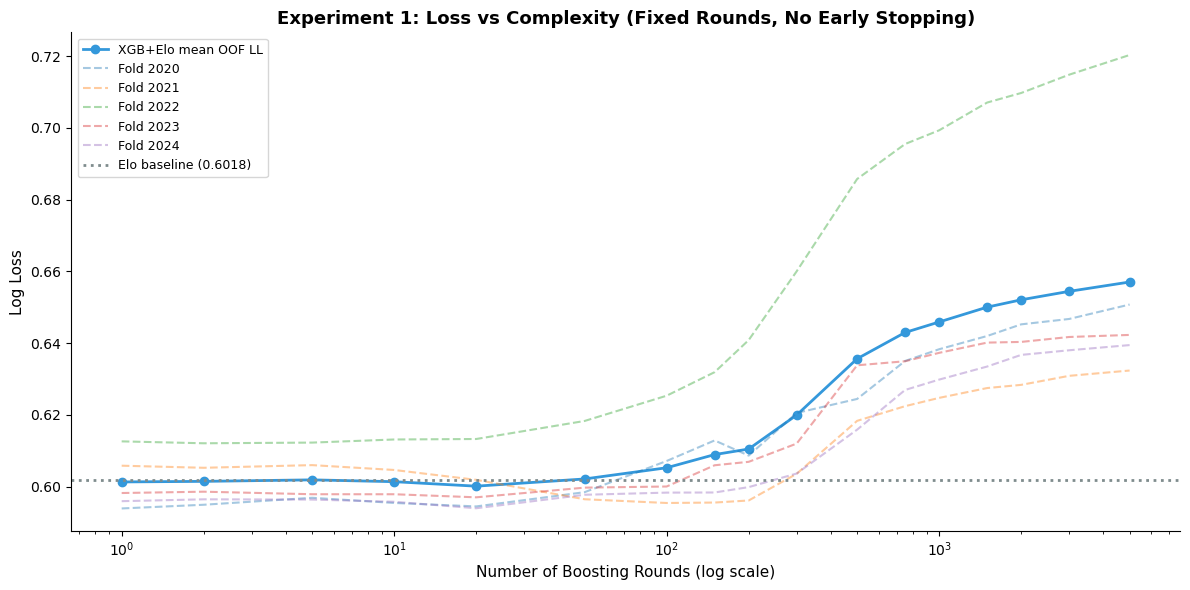

In [7]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(exp1_df["n_rounds"], exp1_df["mean_ll"], "o-", color="#3498db", linewidth=2, label="XGB+Elo mean OOF LL")
for y in OOF_YEARS:
    ax.plot(exp1_df["n_rounds"], exp1_df[f"ll_{y}"], "--", alpha=0.4, label=f"Fold {y}")
ax.axhline(elo_ll_overall, color="#7f8c8d", linestyle=":", linewidth=2, label=f"Elo baseline ({elo_ll_overall:.4f})")
ax.set_xscale("log")
ax.set_xlabel("Number of Boosting Rounds (log scale)", fontsize=11)
ax.set_ylabel("Log Loss", fontsize=11)
ax.set_title("Experiment 1: Loss vs Complexity (Fixed Rounds, No Early Stopping)", fontsize=13, fontweight="bold")
ax.legend(fontsize=9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
fig.savefig(OUT_DIR / "exp1_rounds_curve.png", dpi=150, bbox_inches="tight")
plt.show()

## Experiment 2 — Complexity via Depth (Structural Complexity Axis)

Double descent is about *effective model complexity*, not just rounds.
Depth x rounds is a more natural complexity axis. Test depths 2, 3, 4, 6, 8, 10
each at a range of round counts.

In [8]:
DEPTHS = [2, 3, 4, 6, 8, 10]
ROUNDS_FOR_DEPTH = [10, 50, 100, 200, 500, 1000, 2000, 5000]

exp2_results = []
jobs = [(depth, nr) for depth in DEPTHS for nr in ROUNDS_FOR_DEPTH]
total = len(jobs)
done = 0

with ThreadPoolExecutor(max_workers=N_WORKERS) as ex:
    futures = {ex.submit(_run_one_config, {**BASE_PARAMS, "max_depth": d}, nr): (d, nr)
               for d, nr in jobs}
    for fut in as_completed(futures):
        params_used, n_rounds, fold_lls, mean_ll = fut.result()
        depth = params_used["max_depth"]
        exp2_results.append({"depth": depth, "n_rounds": n_rounds, "mean_ll": mean_ll,
                             **{f"ll_{y}": fold_lls[y] for y in OOF_YEARS}})
        done += 1
        if done % 10 == 0 or done == total:
            print(f"  [{done}/{total}]")

exp2_df = pd.DataFrame(exp2_results).sort_values(["depth", "n_rounds"]).reset_index(drop=True)
exp2_df.to_csv(OUT_DIR / "exp2_depth_rounds.csv", index=False)

for depth in DEPTHS:
    sub = exp2_df[exp2_df["depth"] == depth]
    best = sub.loc[sub["mean_ll"].idxmin()]
    print(f"depth={depth}: best mean_LL={best['mean_ll']:.6f} @ rounds={int(best['n_rounds'])}")
print("Done.")

  [10/48]
  [20/48]
  [30/48]
  [40/48]
  [48/48]
depth=2: best mean_LL=0.602071 @ rounds=10
depth=3: best mean_LL=0.601941 @ rounds=10
depth=4: best mean_LL=0.602046 @ rounds=10
depth=6: best mean_LL=0.601368 @ rounds=10
depth=8: best mean_LL=0.602235 @ rounds=10
depth=10: best mean_LL=0.602540 @ rounds=10
Done.


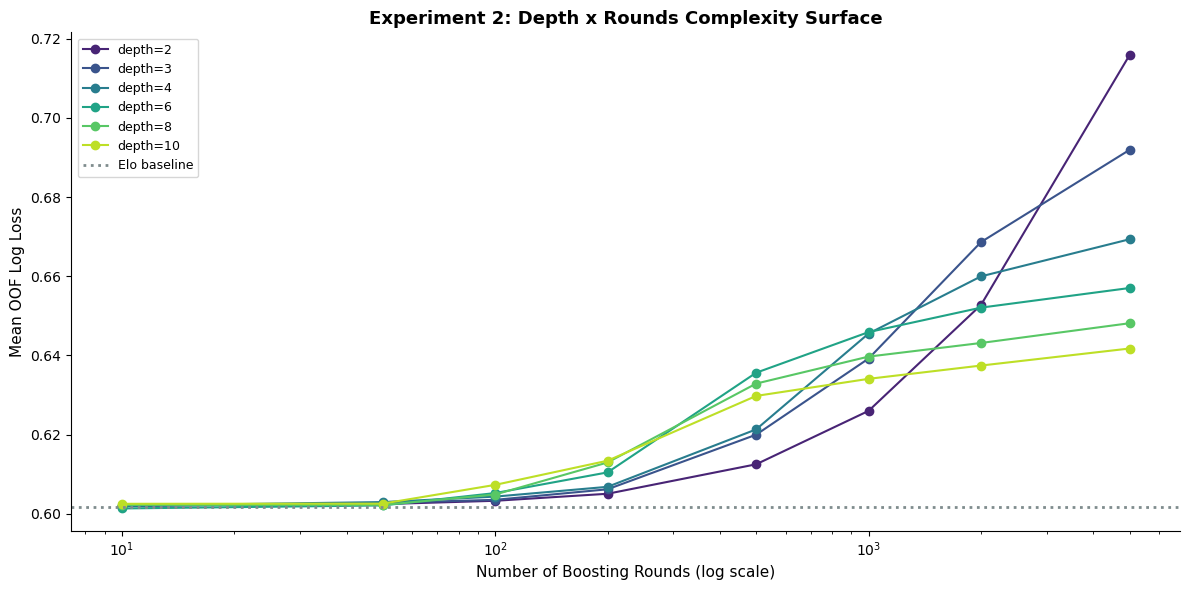

In [9]:
fig, ax = plt.subplots(figsize=(12, 6))
cmap = plt.cm.viridis(np.linspace(0.1, 0.9, len(DEPTHS)))
for i, depth in enumerate(DEPTHS):
    sub = exp2_df[exp2_df["depth"] == depth]
    ax.plot(sub["n_rounds"], sub["mean_ll"], "o-", color=cmap[i], linewidth=1.5, label=f"depth={depth}")
ax.axhline(elo_ll_overall, color="#7f8c8d", linestyle=":", linewidth=2, label="Elo baseline")
ax.set_xscale("log")
ax.set_xlabel("Number of Boosting Rounds (log scale)", fontsize=11)
ax.set_ylabel("Mean OOF Log Loss", fontsize=11)
ax.set_title("Experiment 2: Depth x Rounds Complexity Surface", fontsize=13, fontweight="bold")
ax.legend(fontsize=9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
fig.savefig(OUT_DIR / "exp2_depth_rounds.png", dpi=150, bbox_inches="tight")
plt.show()

## Experiment 3 — Lower Learning Rate + Many Rounds

If double descent exists here, a lower learning rate gives a finer-grained complexity
ramp — each tree contributes less, so you need more trees to reach the interpolation
threshold. This stretches the curve and makes the second descent (if present) easier to spot.

In [10]:
LR_CONFIGS = [
    {"lr": 0.1,   "rounds": [5, 10, 20, 50, 100, 200, 500, 1000, 2000]},
    {"lr": 0.02,  "rounds": [10, 50, 100, 200, 500, 1000, 2000, 5000]},
    {"lr": 0.005, "rounds": [50, 100, 200, 500, 1000, 2000, 5000, 10000]},
]

jobs3 = []
for cfg in LR_CONFIGS:
    for nr in cfg["rounds"]:
        jobs3.append((cfg["lr"], nr))

exp3_results = []
total = len(jobs3)
done = 0

with ThreadPoolExecutor(max_workers=N_WORKERS) as ex:
    futures = {ex.submit(_run_one_config, {**BASE_PARAMS, "learning_rate": lr}, nr): (lr, nr)
               for lr, nr in jobs3}
    for fut in as_completed(futures):
        params_used, n_rounds, fold_lls, mean_ll = fut.result()
        lr = params_used["learning_rate"]
        exp3_results.append({"lr": lr, "n_rounds": n_rounds, "mean_ll": mean_ll,
                             **{f"ll_{y}": fold_lls[y] for y in OOF_YEARS}})
        done += 1
        if done % 5 == 0 or done == total:
            print(f"  [{done}/{total}]")

exp3_df = pd.DataFrame(exp3_results).sort_values(["lr", "n_rounds"]).reset_index(drop=True)
exp3_df.to_csv(OUT_DIR / "exp3_lr_rounds.csv", index=False)

for cfg in LR_CONFIGS:
    lr = cfg["lr"]
    sub = exp3_df[exp3_df["lr"] == lr]
    best = sub.loc[sub["mean_ll"].idxmin()]
    print(f"lr={lr}: best mean_LL={best['mean_ll']:.6f} @ rounds={int(best['n_rounds'])}")
print("Done.")

  [5/25]
  [10/25]
  [15/25]
  [20/25]
  [25/25]
lr=0.1: best mean_LL=0.600552 @ rounds=5
lr=0.02: best mean_LL=0.601368 @ rounds=10
lr=0.005: best mean_LL=0.601065 @ rounds=50
Done.


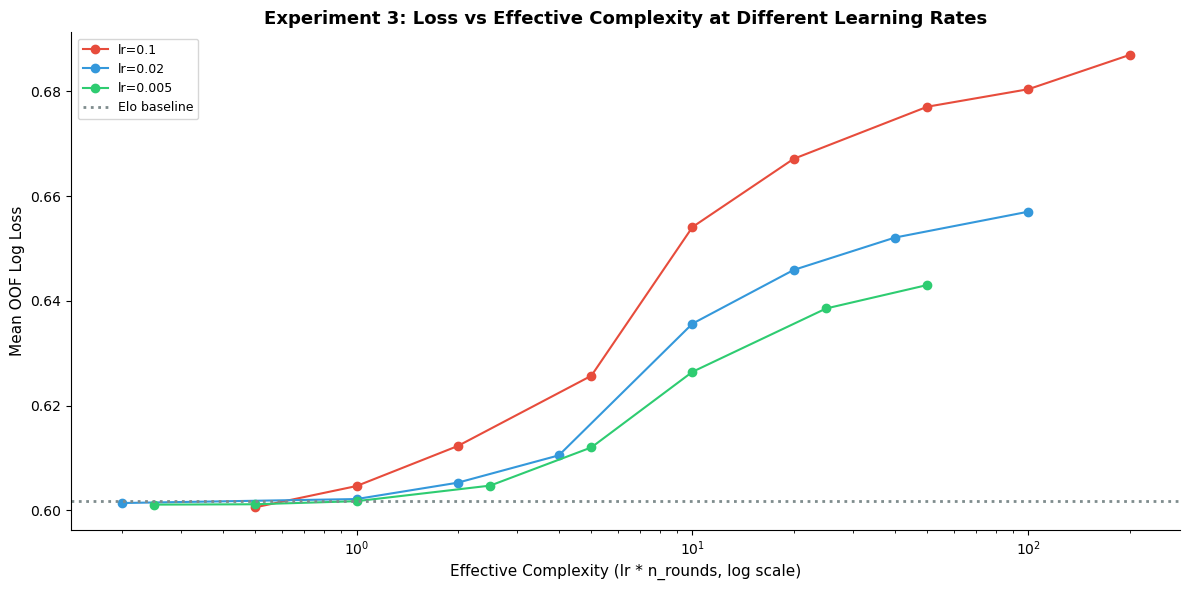

In [11]:
fig, ax = plt.subplots(figsize=(12, 6))
lr_colors = {0.1: "#e74c3c", 0.02: "#3498db", 0.005: "#2ecc71"}
for cfg in LR_CONFIGS:
    lr = cfg["lr"]
    sub = exp3_df[exp3_df["lr"] == lr]
    # Plot vs effective complexity = lr * n_rounds
    eff_complexity = sub["lr"] * sub["n_rounds"]
    ax.plot(eff_complexity, sub["mean_ll"], "o-", color=lr_colors[lr], linewidth=1.5, label=f"lr={lr}")
ax.axhline(elo_ll_overall, color="#7f8c8d", linestyle=":", linewidth=2, label="Elo baseline")
ax.set_xscale("log")
ax.set_xlabel("Effective Complexity (lr * n_rounds, log scale)", fontsize=11)
ax.set_ylabel("Mean OOF Log Loss", fontsize=11)
ax.set_title("Experiment 3: Loss vs Effective Complexity at Different Learning Rates", fontsize=13, fontweight="bold")
ax.legend(fontsize=9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
fig.savefig(OUT_DIR / "exp3_lr_rounds.png", dpi=150, bbox_inches="tight")
plt.show()

## Experiment 4 — Constrained Configs

Test whether a structurally simpler model extracts signal more cleanly:
- Shallow trees (depth 2-3) force the model to find the strongest splits first
- Higher min_child_weight prevents spurious splits on small subgroups
- Lower colsample_bytree forces diversity, breaks player-block dominance

Each config runs the full round schedule to see its own curve shape.

In [12]:
CONSTRAINED_CONFIGS = {
    "baseline": BASE_PARAMS,
    "shallow_d2": {**BASE_PARAMS, "max_depth": 2},
    "shallow_d3": {**BASE_PARAMS, "max_depth": 3},
    "high_mcw": {**BASE_PARAMS, "min_child_weight": 15, "gamma": 3.0},
    "low_colsample": {**BASE_PARAMS, "colsample_bytree": 0.2},
    "stump_ensemble": {**BASE_PARAMS, "max_depth": 1, "learning_rate": 0.005},
    "constrained_combo": {**BASE_PARAMS, "max_depth": 3, "min_child_weight": 10,
                          "colsample_bytree": 0.3, "learning_rate": 0.01},
}

ROUNDS_EXP4 = [10, 50, 100, 200, 500, 1000, 2000, 5000]

jobs4 = [(name, params, nr) for name, params in CONSTRAINED_CONFIGS.items() for nr in ROUNDS_EXP4]
total = len(jobs4)
done = 0

exp4_results = []
with ThreadPoolExecutor(max_workers=N_WORKERS) as ex:
    futures = {ex.submit(_run_one_config, params, nr): (name, nr)
               for name, params, nr in jobs4}
    for fut in as_completed(futures):
        name, nr = futures[fut]
        _, n_rounds, fold_lls, mean_ll = fut.result()
        exp4_results.append({"config": name, "n_rounds": n_rounds, "mean_ll": mean_ll,
                             **{f"ll_{y}": fold_lls[y] for y in OOF_YEARS}})
        done += 1
        if done % 10 == 0 or done == total:
            print(f"  [{done}/{total}]")

exp4_df = pd.DataFrame(exp4_results).sort_values(["config", "n_rounds"]).reset_index(drop=True)
exp4_df.to_csv(OUT_DIR / "exp4_constrained.csv", index=False)

for config_name in CONSTRAINED_CONFIGS:
    sub = exp4_df[exp4_df["config"] == config_name]
    best = sub.loc[sub["mean_ll"].idxmin()]
    print(f"{config_name:22s}: best mean_LL={best['mean_ll']:.6f} @ rounds={int(best['n_rounds'])}")
print("Done.")

  [10/56]
  [20/56]
  [30/56]
  [40/56]
  [50/56]
  [56/56]
baseline              : best mean_LL=0.601368 @ rounds=10
shallow_d2            : best mean_LL=0.602071 @ rounds=10
shallow_d3            : best mean_LL=0.601941 @ rounds=10
high_mcw              : best mean_LL=0.602564 @ rounds=10
low_colsample         : best mean_LL=0.602572 @ rounds=10
stump_ensemble        : best mean_LL=0.601857 @ rounds=10
constrained_combo     : best mean_LL=0.601480 @ rounds=50
Done.


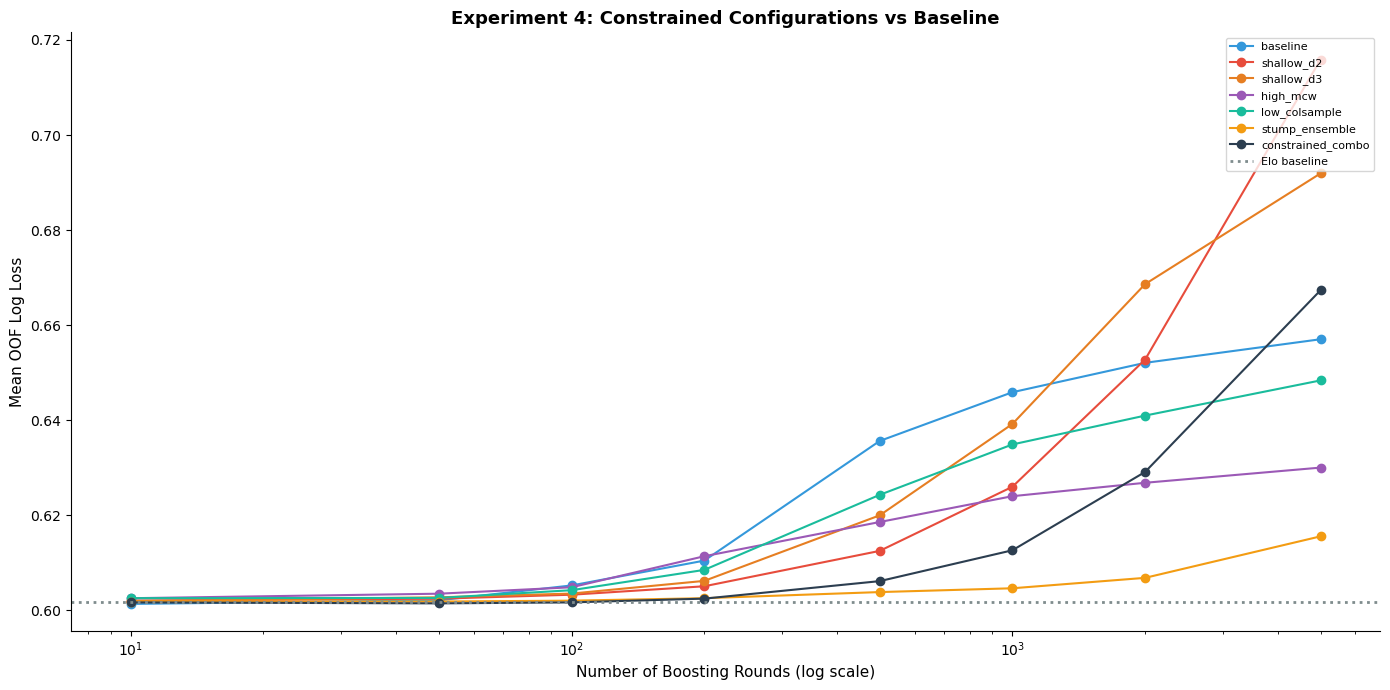

In [13]:
fig, ax = plt.subplots(figsize=(14, 7))
config_colors = {
    "baseline":         "#3498db",
    "shallow_d2":       "#e74c3c",
    "shallow_d3":       "#e67e22",
    "high_mcw":         "#9b59b6",
    "low_colsample":    "#1abc9c",
    "stump_ensemble":   "#f39c12",
    "constrained_combo": "#2c3e50",
}
for config_name in CONSTRAINED_CONFIGS:
    sub = exp4_df[exp4_df["config"] == config_name]
    ax.plot(sub["n_rounds"], sub["mean_ll"], "o-", color=config_colors[config_name],
            linewidth=1.5, label=config_name)
ax.axhline(elo_ll_overall, color="#7f8c8d", linestyle=":", linewidth=2, label="Elo baseline")
ax.set_xscale("log")
ax.set_xlabel("Number of Boosting Rounds (log scale)", fontsize=11)
ax.set_ylabel("Mean OOF Log Loss", fontsize=11)
ax.set_title("Experiment 4: Constrained Configurations vs Baseline", fontsize=13, fontweight="bold")
ax.legend(fontsize=8, loc="upper right")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
fig.savefig(OUT_DIR / "exp4_constrained.png", dpi=150, bbox_inches="tight")
plt.show()

## Experiment 5 — Train Loss vs Test Loss (Overfitting Diagnostic)

To confirm whether we're in the interpolation regime, track train loss alongside test loss.
In classical double descent, the interpolation peak occurs when train loss approaches zero.
If train loss is still high when test loss starts rising, we're in classical overfitting, not
interpolation — and pushing further won't help.

In [14]:
# Use one representative fold (2024) for detailed train/test curve
fd = fold_data[2024]
dm_train = xgb.DMatrix(data=fd["X_train"], label=fd["y_train"],
                        base_margin=fd["bm_train"], missing=np.nan)
dm_test  = xgb.DMatrix(data=fd["X_test"], label=fd["y_test"],
                        base_margin=fd["bm_test"], missing=np.nan)

evals_result = {}
model_5k = xgb.train(
    BASE_PARAMS, dm_train,
    num_boost_round=5000,
    evals=[(dm_train, "train"), (dm_test, "test")],
    evals_result=evals_result,
    verbose_eval=False,
)

train_ll = evals_result["train"]["logloss"]
test_ll  = evals_result["test"]["logloss"]
print(f"Fold 2024: {len(train_ll)} rounds tracked")
print(f"  Train LL: {train_ll[0]:.4f} -> {train_ll[-1]:.4f}")
print(f"  Test  LL: {test_ll[0]:.4f} -> {test_ll[-1]:.4f}")
print(f"  Best test LL: {min(test_ll):.6f} @ round {np.argmin(test_ll)+1}")

Fold 2024: 5000 rounds tracked
  Train LL: 0.6162 -> 0.1196
  Test  LL: 0.5959 -> 0.6395
  Best test LL: 0.593803 @ round 22


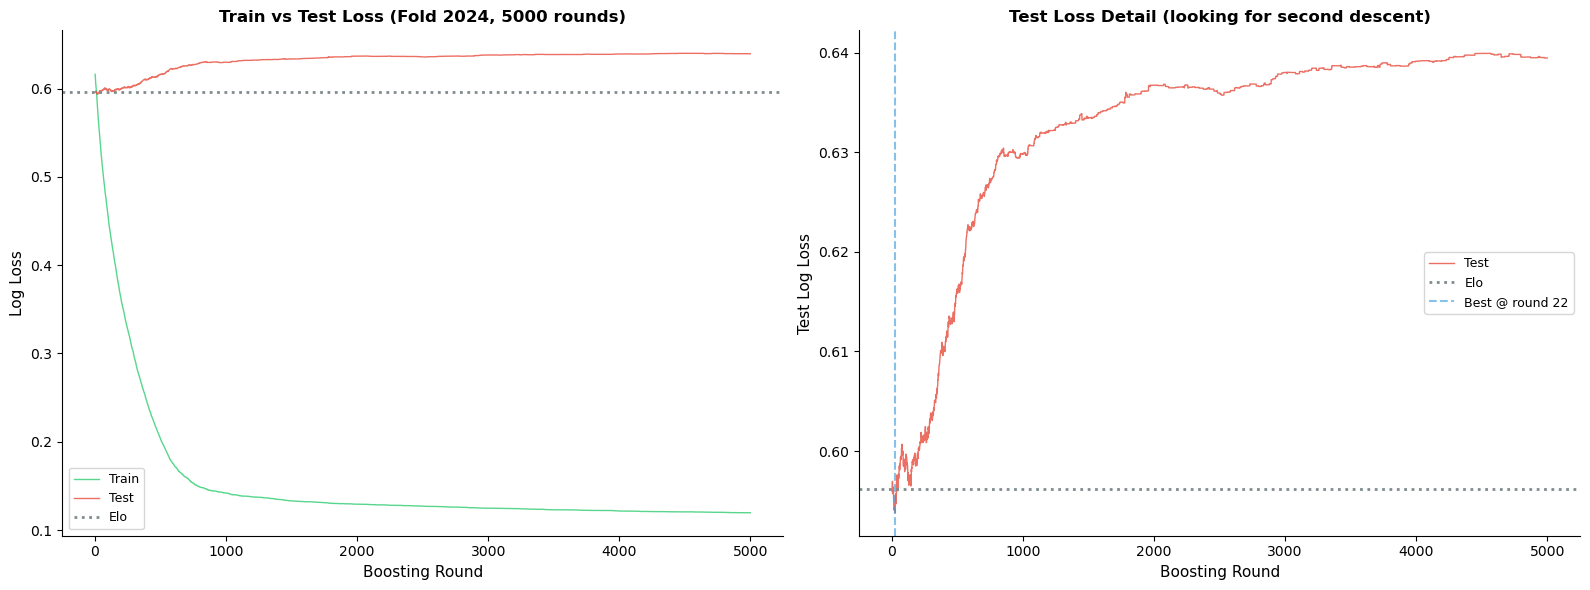

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

rounds = np.arange(1, len(train_ll) + 1)

# Left: full range
ax1.plot(rounds, train_ll, color="#2ecc71", linewidth=1, alpha=0.8, label="Train")
ax1.plot(rounds, test_ll, color="#e74c3c", linewidth=1, alpha=0.8, label="Test")
ax1.axhline(elo_ll_per_fold[2024], color="#7f8c8d", linestyle=":", linewidth=2, label="Elo")
ax1.set_xlabel("Boosting Round", fontsize=11)
ax1.set_ylabel("Log Loss", fontsize=11)
ax1.set_title("Train vs Test Loss (Fold 2024, 5000 rounds)", fontsize=12, fontweight="bold")
ax1.legend(fontsize=9)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

# Right: zoomed into test loss
ax2.plot(rounds, test_ll, color="#e74c3c", linewidth=1, alpha=0.8, label="Test")
ax2.axhline(elo_ll_per_fold[2024], color="#7f8c8d", linestyle=":", linewidth=2, label="Elo")
best_idx = np.argmin(test_ll)
ax2.axvline(best_idx + 1, color="#3498db", linestyle="--", alpha=0.6, label=f"Best @ round {best_idx+1}")
ax2.set_xlabel("Boosting Round", fontsize=11)
ax2.set_ylabel("Test Log Loss", fontsize=11)
ax2.set_title("Test Loss Detail (looking for second descent)", fontsize=12, fontweight="bold")
ax2.legend(fontsize=9)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

plt.tight_layout()
fig.savefig(OUT_DIR / "exp5_train_test_curve.png", dpi=150, bbox_inches="tight")
plt.show()

## Summary Table — Best Config Per Experiment

In [16]:
summary_rows = []

# Elo baseline
summary_rows.append({"experiment": "Elo baseline", "config": "-", "best_rounds": "-", "mean_oof_ll": elo_ll_overall})

# Exp1: best from fixed rounds
best1 = exp1_df.loc[exp1_df["mean_ll"].idxmin()]
summary_rows.append({"experiment": "Exp1: fixed rounds", "config": "baseline params",
                      "best_rounds": int(best1["n_rounds"]), "mean_oof_ll": best1["mean_ll"]})

# Exp2: best per depth
for depth in DEPTHS:
    sub = exp2_df[exp2_df["depth"] == depth]
    best = sub.loc[sub["mean_ll"].idxmin()]
    summary_rows.append({"experiment": "Exp2: depth scan", "config": f"depth={depth}",
                          "best_rounds": int(best["n_rounds"]), "mean_oof_ll": best["mean_ll"]})

# Exp3: best per LR
for cfg in LR_CONFIGS:
    lr = cfg["lr"]
    sub = exp3_df[exp3_df["lr"] == lr]
    best = sub.loc[sub["mean_ll"].idxmin()]
    summary_rows.append({"experiment": "Exp3: LR scan", "config": f"lr={lr}",
                          "best_rounds": int(best["n_rounds"]), "mean_oof_ll": best["mean_ll"]})

# Exp4: best per constrained config
for config_name in CONSTRAINED_CONFIGS:
    sub = exp4_df[exp4_df["config"] == config_name]
    best = sub.loc[sub["mean_ll"].idxmin()]
    summary_rows.append({"experiment": "Exp4: constrained", "config": config_name,
                          "best_rounds": int(best["n_rounds"]), "mean_oof_ll": best["mean_ll"]})

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.sort_values("mean_oof_ll").reset_index(drop=True)
summary_df.to_csv(OUT_DIR / "summary_all_experiments.csv", index=False)
print(summary_df.to_string(index=False))

        experiment            config best_rounds  mean_oof_ll
Exp1: fixed rounds   baseline params          20     0.600118
     Exp3: LR scan            lr=0.1           5     0.600552
     Exp3: LR scan          lr=0.005          50     0.601065
  Exp2: depth scan           depth=6          10     0.601368
 Exp4: constrained          baseline          10     0.601368
     Exp3: LR scan           lr=0.02          10     0.601368
 Exp4: constrained constrained_combo          50     0.601480
      Elo baseline                 -           -     0.601842
 Exp4: constrained    stump_ensemble          10     0.601857
  Exp2: depth scan           depth=3          10     0.601941
 Exp4: constrained        shallow_d3          10     0.601941
  Exp2: depth scan           depth=4          10     0.602046
  Exp2: depth scan           depth=2          10     0.602071
 Exp4: constrained        shallow_d2          10     0.602071
  Exp2: depth scan           depth=8          10     0.602235
  Exp2: 